# Oscilloscope - Waveform Visualization

This notebook demonstrates a digital oscilloscope displaying different wave types (sine, cosine, square, sawtooth, triangle) and frequencies using matplotlib.

Use the slider controls to adjust frequency and see how the waveforms change in real-time.

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Play, IntSlider, jslink, HBox, VBox, Output
from IPython.display import display

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.facecolor'] = '#0a0a12'
plt.rcParams['axes.grid'] = True

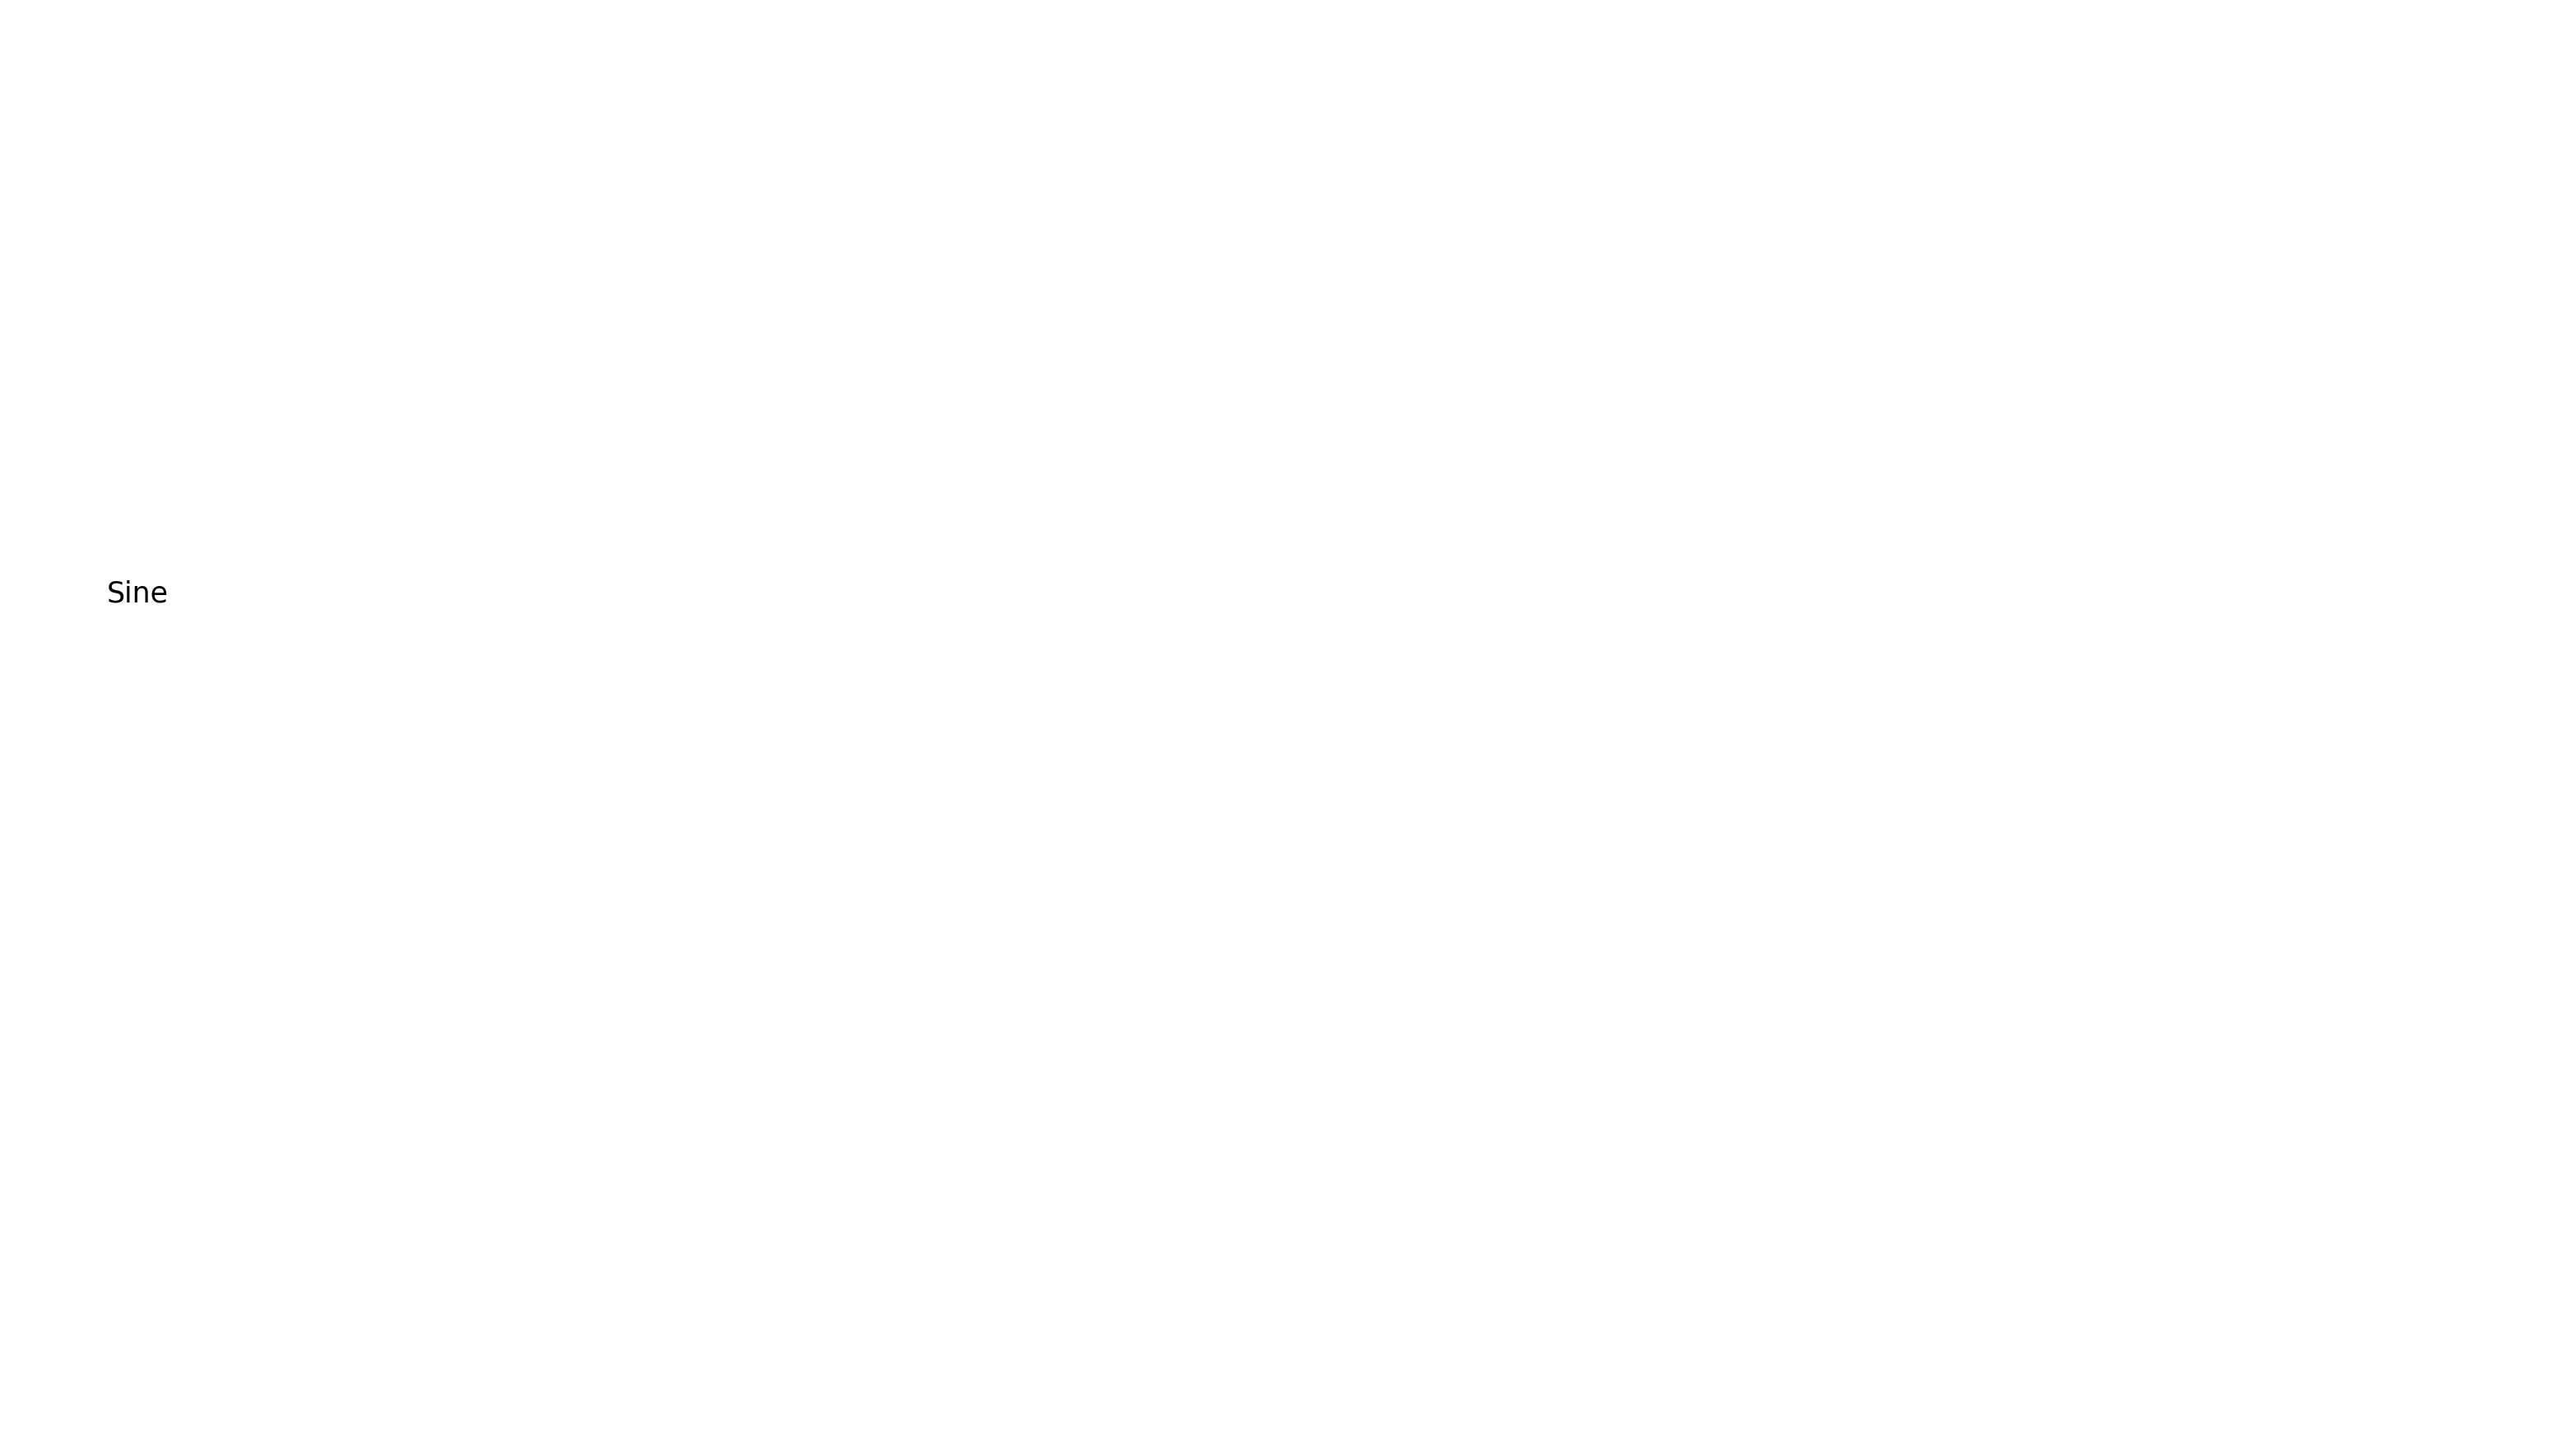

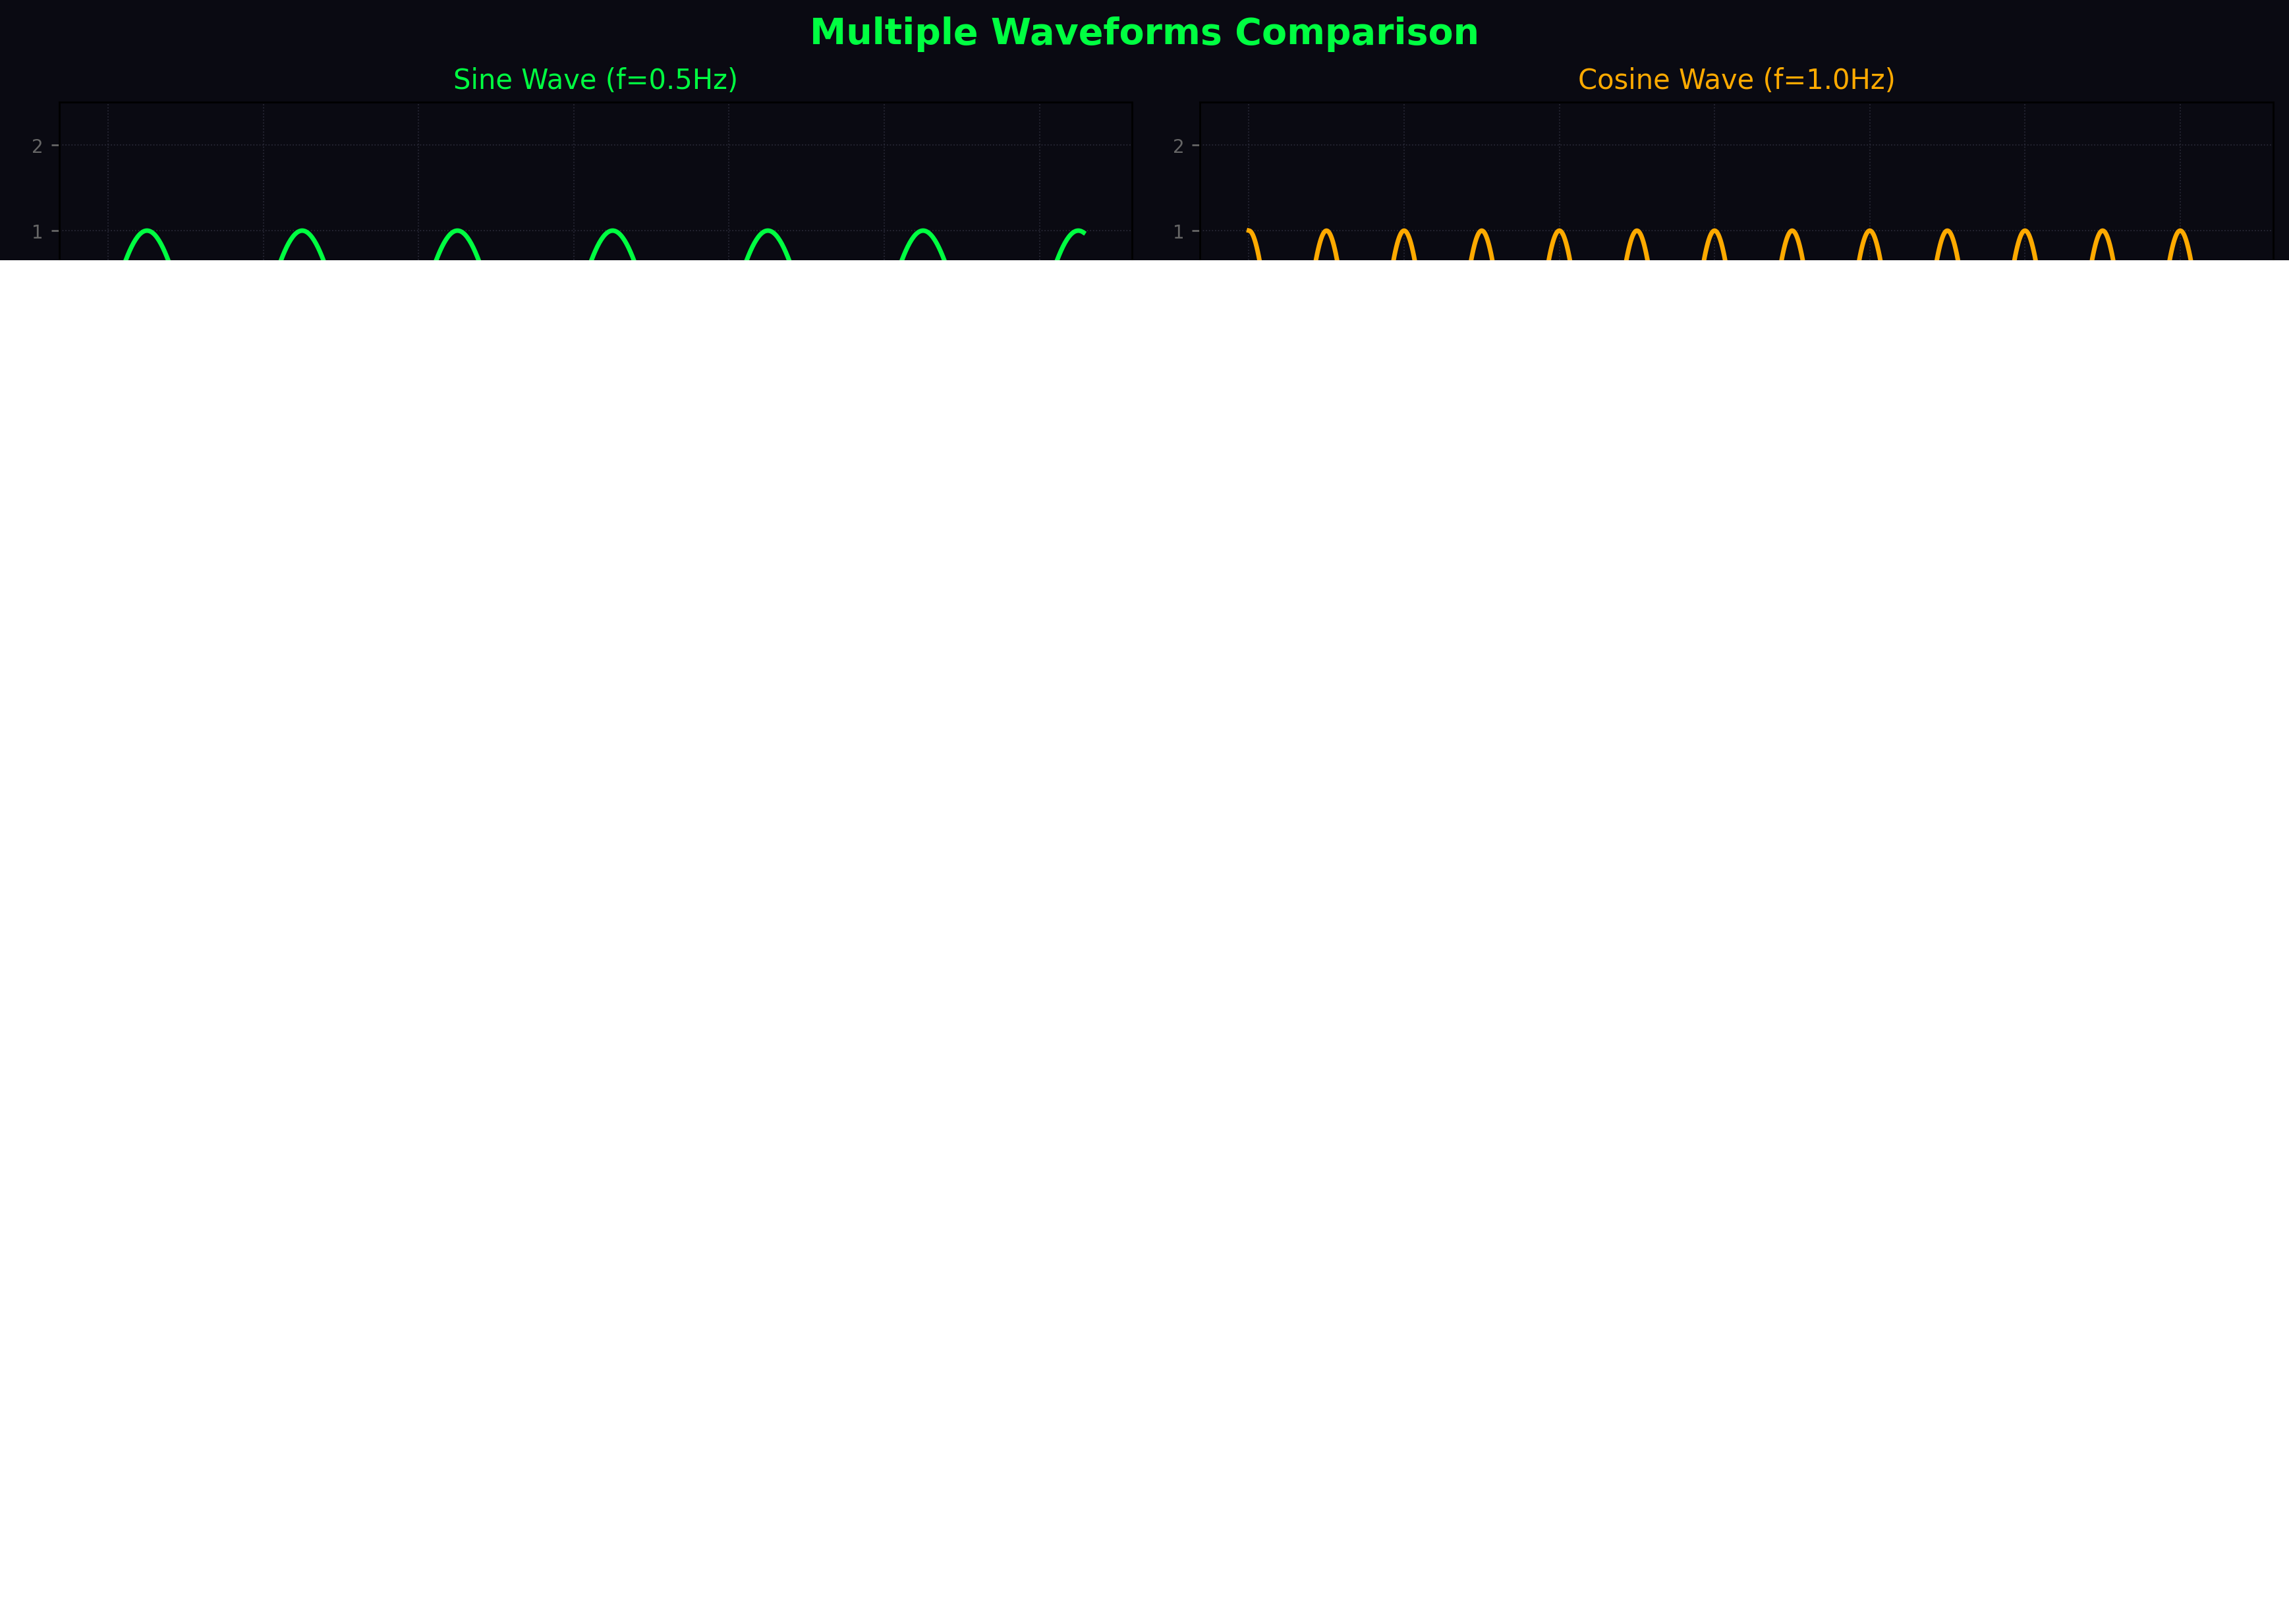

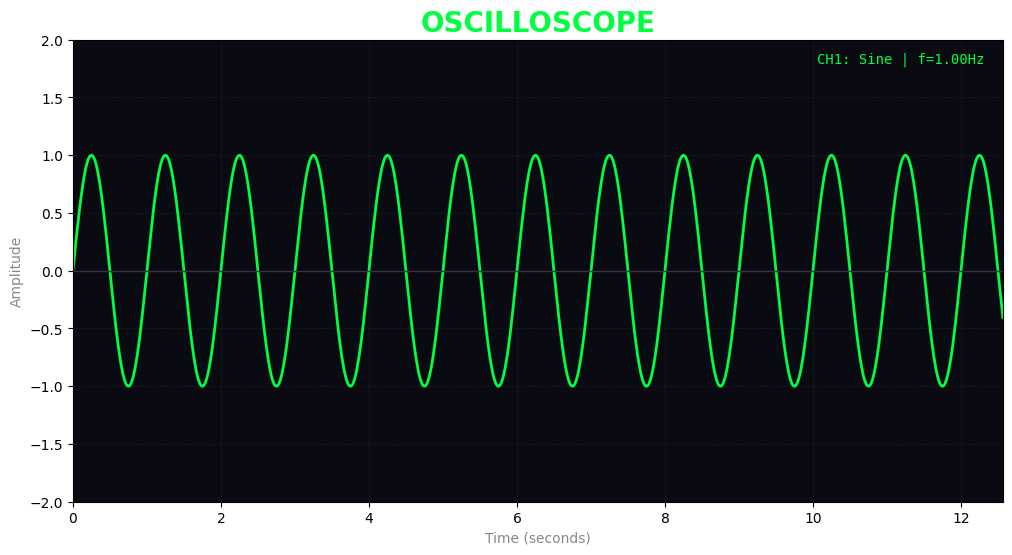

In [5]:
# Time array
t = np.linspace(0, 4*np.pi, 1000)

# Wave functions
def sine_wave(t, freq):
    return np.sin(2 * np.pi * freq * t)

def cosine_wave(t, freq):
    return np.cos(2 * np.pi * freq * t)

def square_wave(t, freq):
    return np.sign(np.sin(2 * np.pi * freq * t))

def sawtooth_wave(t, freq):
    return 2 * (t * freq - np.floor(t * freq + 0.5))

def triangle_wave(t, freq):
    return 2 * np.abs(2 * (t * freq - np.floor(t * freq + 0.5))) - 1

# Wave dictionary with functions
wave_dict = {
    'Sine': sine_wave,
    'Cosine': cosine_wave,
    'Square': square_wave,
    'Sawtooth': sawtooth_wave,
    'Triangle': triangle_wave
}

# Color map for different waves
wave_colors = {
    'Sine': '#00ff41',
    'Cosine': '#ffaa00',
    'Square': '#ff0044',
    'Sawtooth': '#aa00ff',
    'Triangle': '#00aaff'
}

# Create figure and output widget
frames = 100
play = Play(value=0, min=0, max=frames-1, step=1, interval=50)
slider = IntSlider(value=0, min=0, max=frames-1, description='Frame', readout=False)
jslink((play, 'value'), (slider, 'value'))

out = Output()
fig, ax = plt.subplots(figsize=(12, 6))

# Initial plot
line, = ax.plot(t, sine_wave(t, 1), color=wave_colors['Sine'], linewidth=2)
ax.axhline(y=0, color='#333344', linestyle='-', linewidth=1)
ax.set_facecolor('#0a0a12')
ax.grid(True, color='#2a2a38', linestyle=':', linewidth=0.5)
ax.set_title('OSCILLOSCOPE', color='#00ff41', fontsize=20, weight='bold')
ax.set_xlabel('Time (seconds)', color='#888888')
ax.set_ylabel('Amplitude', color='#888888')
ax.set_ylim(-2, 2)
ax.set_xlim(0, 4*np.pi)

# Status text
status_text = ax.text(0.98, 0.95, '', transform=ax.transAxes,
                      color='#00ff41', fontsize=10, fontfamily='monospace', ha='right')

def render(frame):
    freq = 1 + frame / frames * 4
    line.set_ydata(sine_wave(t, freq))
    status_text.set_text(f'CH1: Sine | f={freq:.2f}Hz')
    out.clear_output(wait=True)
    with out:
        display(fig)

def on_frame(change):
    render(change['new'])

slider.observe(on_frame, names='value')
play.observe(on_frame, names='value')

render(0)
display(VBox([out, HBox([play, slider])]))

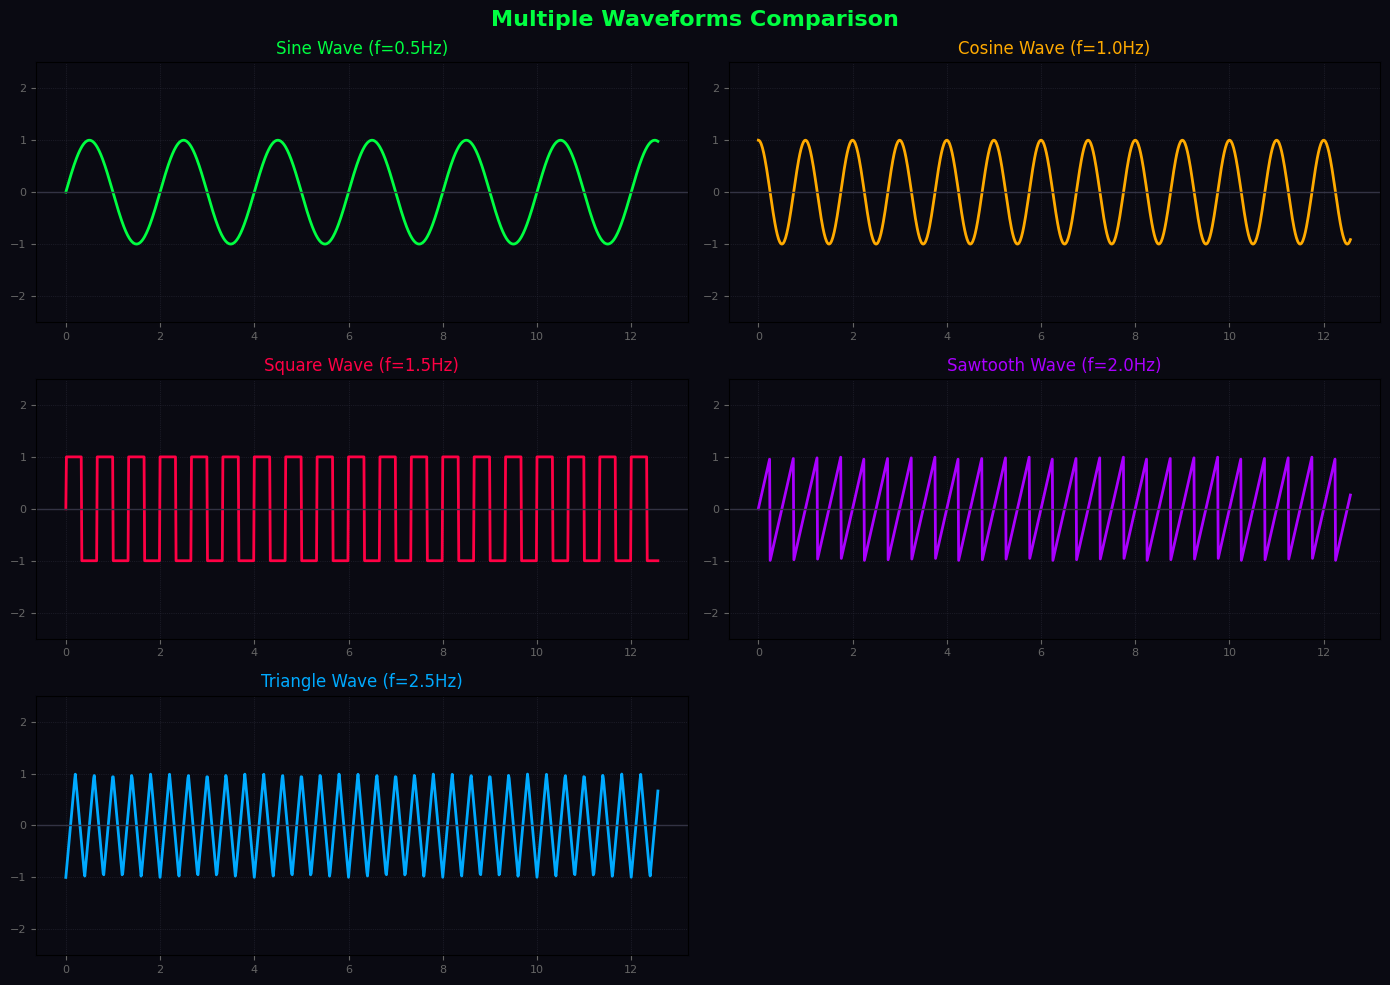

In [6]:
# Additional visualization: All waves at once

fig2, axes = plt.subplots(3, 2, figsize=(14, 10))
fig2.patch.set_facecolor('#0a0a12')

frequencies = [0.5, 1.0, 1.5, 2.0, 2.5]

for idx, (name, wave_fn) in enumerate(wave_dict.items()):
    ax = axes[idx // 2, idx % 2]
    freq = frequencies[idx]
    y = wave_fn(t, freq)
    
    ax.plot(t, y, color=wave_colors[name], linewidth=2)
    ax.axhline(y=0, color='#333344', linestyle='-', linewidth=1)
    ax.set_facecolor('#0a0a12')
    ax.grid(True, color='#2a2a38', linestyle=':', linewidth=0.5)
    ax.set_title(f'{name} Wave (f={freq}Hz)', color=wave_colors[name], fontsize=12)
    ax.set_ylim(-2.5, 2.5)
    ax.tick_params(colors='#666666', labelsize=8)

axes[2, 1].set_visible(False)

plt.suptitle('Multiple Waveforms Comparison', color='#00ff41', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

## Oscilloscope Controls

**Frame Slider** (bottom): Controls the frequency of the displayed waveform from 1Hz to 5Hz

**Wave Type**: Currently fixed to Sine - use the code below to explore other waveforms

---
*Created with Jupyter & agent-client-kernel*